In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('mushrooms.csv')


In [3]:
dataset.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
from sklearn.preprocessing import LabelEncoder
data = dataset.astype('category')

In [5]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV

In [6]:

l = LabelEncoder()
for column in data.columns:
    data[column]=l.fit_transform(data[column])

In [7]:
x= data.drop('class',axis=1)
y =data["class"]

In [8]:
from sklearn.decomposition import PCA
pca1 =PCA(n_components=5)
pca_fit = pca1.fit_transform(x)

In [9]:
pca1.explained_variance_ratio_

array([0.33758733, 0.16581098, 0.12285821, 0.06796611, 0.05831173])

In [10]:
sum(pca1.explained_variance_ratio_)*100

75.25343713718

In [11]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% temporary data
x_train, x_temp, y_train, y_temp = train_test_split(pca_fit, y, test_size=0.20, random_state=42)

# Split the 20% temporary data into 50% validation and 50% testing
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import BayesianRidge

In [13]:

models = {
    'LR': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(),
    'DTC': DecisionTreeClassifier(),
    'RFC': RandomForestClassifier(),
    'GBC': GradientBoostingClassifier(),
    'BR': BayesianRidge()
}

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Train and evaluate models
for name, model in models.items():
    # Fit the model
    model.fit(x_train, y_train)

    # Predict on the test set
    y_pred = model.predict(x_test)

    # For Bayesian Ridge, convert predictions to binary (use 0.5 threshold)
    if name == 'BR':
        y_pred = (y_pred > 0.5).astype(int)  # Convert continuous values to binary

    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Print metrics for each model
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 50)

LR Performance:
Accuracy: 0.8350
Precision: 0.8366
Recall: 0.8350
F1 Score: 0.8346
--------------------------------------------------
KNN Performance:
Accuracy: 0.9889
Precision: 0.9890
Recall: 0.9889
F1 Score: 0.9889
--------------------------------------------------
SVC Performance:
Accuracy: 0.9458
Precision: 0.9485
Recall: 0.9458
F1 Score: 0.9457
--------------------------------------------------
DTC Performance:
Accuracy: 0.9815
Precision: 0.9816
Recall: 0.9815
F1 Score: 0.9815
--------------------------------------------------
RFC Performance:
Accuracy: 0.9951
Precision: 0.9951
Recall: 0.9951
F1 Score: 0.9951
--------------------------------------------------
GBC Performance:
Accuracy: 0.9286
Precision: 0.9294
Recall: 0.9286
F1 Score: 0.9285
--------------------------------------------------
BR Performance:
Accuracy: 0.8325
Precision: 0.8346
Recall: 0.8325
F1 Score: 0.8321
--------------------------------------------------


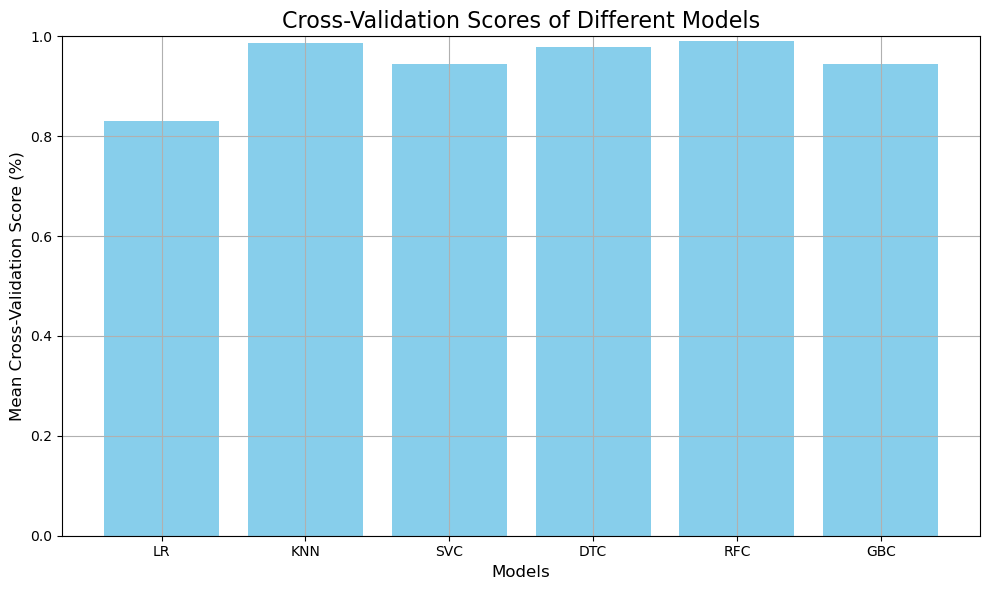

LR: 83.11%
KNN: 98.69%
SVC: 94.41%
DTC: 97.77%
RFC: 98.98%
GBC: 94.41%


In [15]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize the models (only classification models)
models = [
    LogisticRegression(),
    KNeighborsClassifier(),
    SVC(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier()
]

model_names = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC']

# Initialize a list to store the mean cross-validation scores
cv_scores = []

# For each model, perform cross-validation and get the mean score
for model in models:
    cv_score = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_scores.append(cv_score.mean())

# Create a bar plot to visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.bar(model_names, cv_scores, color='skyblue')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Mean Cross-Validation Score (%)', fontsize=12)
plt.title('Cross-Validation Scores of Different Models', fontsize=16)
plt.ylim(0, 1)  # The score is between 0 and 1
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

# Optionally, print out the cross-validation scores for each model
for name, score in zip(model_names, cv_scores):
    print(f"{name}: {score * 100:.2f}%")



In [16]:
from joblib import dump, load

dump((x_train, y_train), 'train.joblib')
dump((x_test, y_test), 'test.joblib')
dump((x_val, y_val), 'val.joblib')

['val.joblib']

In [34]:
from joblib import load

# Load the test dataset correctly
x_test, y_test = load("test.joblib")


In [36]:
import numpy as np

np.save('x_train.npy', x_train)
np.save('y_train.npy', y_train)
np.save('x_test.npy', x_test)
np.save('y_test.npy', y_test)
np.save('x_val.npy', x_val)
np.save('y_val.npy', y_val)

# Loading later
x_train = np.load('x_train.npy')


In [38]:
print(f"Training set: {len(x_train)} samples")
print(f"Testing set: {len(x_test)} samples")
print(f"Validation set: {len(x_val)} samples")


Training set: 6499 samples
Testing set: 812 samples
Validation set: 813 samples
